In [8]:
import pandas as pd

# Load the diabetes dataset
df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")

# Display the first five rows
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### Dataset Preview

The dataset contains 253,680 observations and 22 columns, including the target variable `Diabetes_012` and 21 predictor variables. The target variable represents three diabetes-status classes: 0 (No Diabetes), 1 (Prediabetes), and 2 (Diabetes).

The predictor variables include demographic, health, lifestyle, and healthcare-related characteristics, such as `HighBP`, `HighChol`, `BMI`, `Smoker`, `Stroke`, `HeartDiseaseorAttack`, `PhysActivity`, `Fruits`, `GenHlth`, `MentHlth`, `PhysHlth`, `DiffWalk`, `Sex`, `Age`, `Education`, and `Income`.

The first five rows are displayed to provide an overview of the dataset structure and the format of the variables. Most variables are numerically encoded, while `BMI` is represented as a continuous numerical measure. The target variable `Diabetes_012` is used as the dependent variable for the three-class classification task.

In [31]:
# Check missing values in all columns

missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values by column:
Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Total missing values: 0


### 2.4 Missing Data

The dataset was examined for missing values before the exploratory analysis and machine learning model development. Missing-value counts were calculated for all 22 variables, including the target variable and the 21 predictor variables.

The analysis identified **0 missing values** across the 253,680 observations. Therefore, no imputation or missing-value replacement was required, and the original dataset was retained for subsequent analysis.

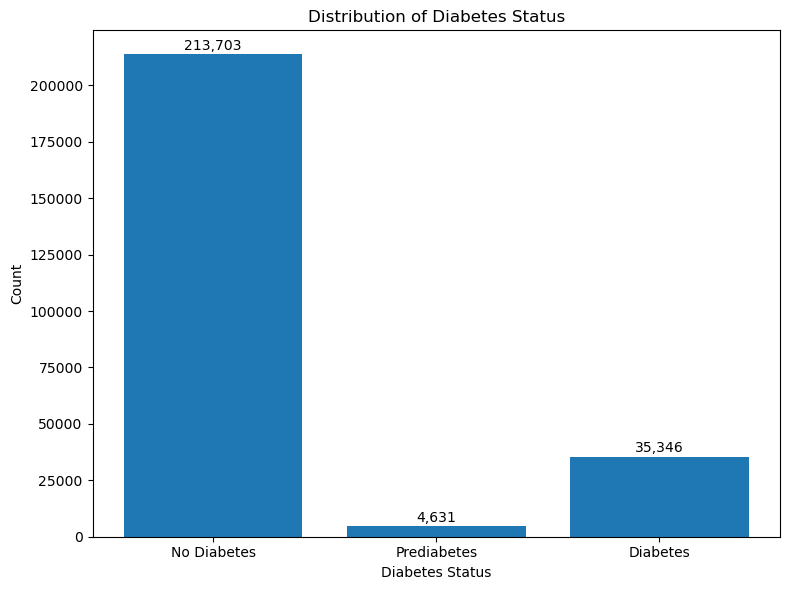

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# Count diabetes-status classes
target_counts = df["Diabetes_012"].value_counts().sort_index()

# Plot
plt.figure(figsize=(8, 6))

bars = plt.bar(
    ["No Diabetes", "Prediabetes", "Diabetes"],
    target_counts.values
)

plt.xlabel("Diabetes Status")
plt.ylabel("Count")
plt.title("Distribution of Diabetes Status")

# Add counts above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2000,
        f"{int(height):,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Distribution of Diabetes Status

The distribution of the target variable shows substantial class imbalance in the dataset. Most observations belong to the No Diabetes class, while the Prediabetes class represents a much smaller proportion of the data. The Diabetes class is also considerably larger than the Prediabetes class. This class imbalance is an important consideration when developing and evaluating the classification models.

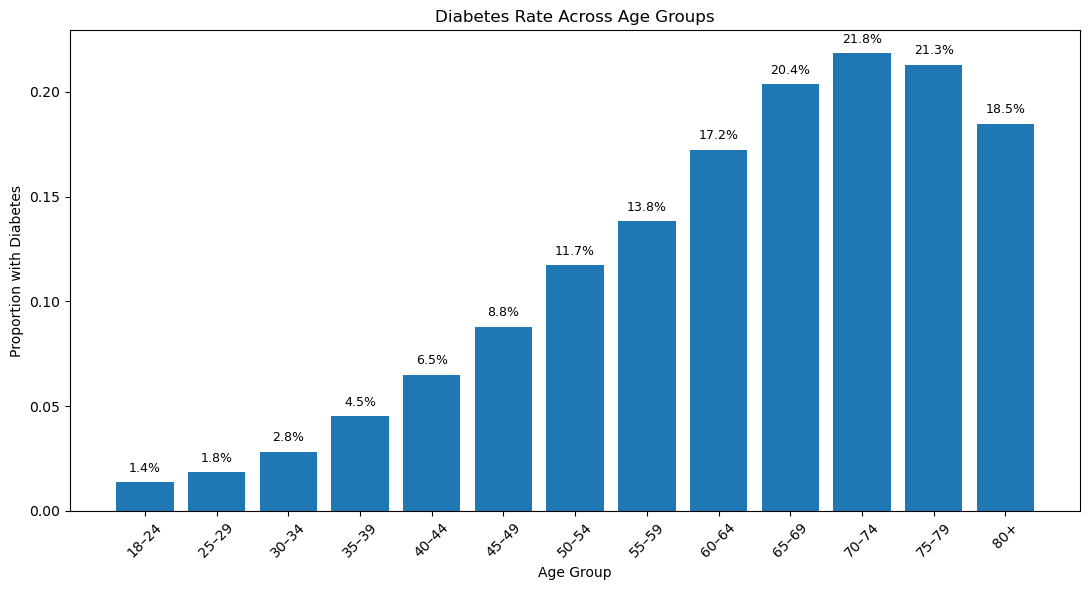

In [23]:
import matplotlib.pyplot as plt

# Age group labels from the BRFSS 2015 coding
age_labels = [
    "18–24", "25–29", "30–34", "35–39",
    "40–44", "45–49", "50–54", "55–59",
    "60–64", "65–69", "70–74", "75–79", "80+"
]

# Calculate diabetes proportion within each age group
age_diabetes = (
    df.groupby("Age")["Diabetes_012"]
    .apply(lambda x: (x == 2).mean())
)

plt.figure(figsize=(11, 6))

bars = plt.bar(
    age_labels,
    age_diabetes.values
)

plt.xlabel("Age Group")
plt.ylabel("Proportion with Diabetes")
plt.title("Diabetes Rate Across Age Groups")

# Add percentages
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.1%}",
        ha="center",
        fontsize=9
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Figure X shows the proportion of observations classified as Diabetes across the 13 age groups in the dataset. The proportion generally increases with age, rising from 1.4% among individuals aged 18–24 (age group 1) to 21.8% among individuals aged 70–74 (age group 11). The proportion then decreases slightly in the 75–79 and 80+ age groups. Overall, the figure shows a clear variation in diabetes status across age groups.

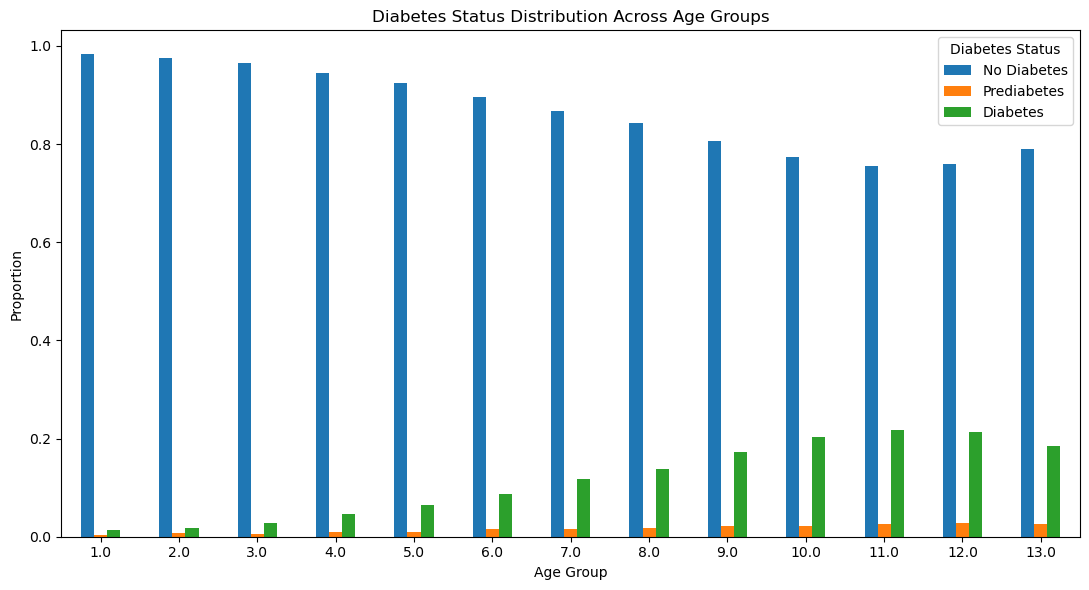

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate proportions within each age group
age_status = pd.crosstab(
    df["Age"],
    df["Diabetes_012"],
    normalize="index"
)

# Plot
ax = age_status.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.xlabel("Age Group")
plt.ylabel("Proportion")
plt.title("Diabetes Status Distribution Across Age Groups")

plt.legend(
    ["No Diabetes", "Prediabetes", "Diabetes"],
    title="Diabetes Status"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Figure X presents the distribution of the three diabetes-status classes across the different age groups. The proportion of observations classified as No Diabetes generally decreases as age increases, while the proportion classified as Diabetes increases. The Prediabetes class remains relatively small across all age groups. These results highlight the strong variation in diabetes-status distribution across age categories and provide useful context for the three-class classification task.


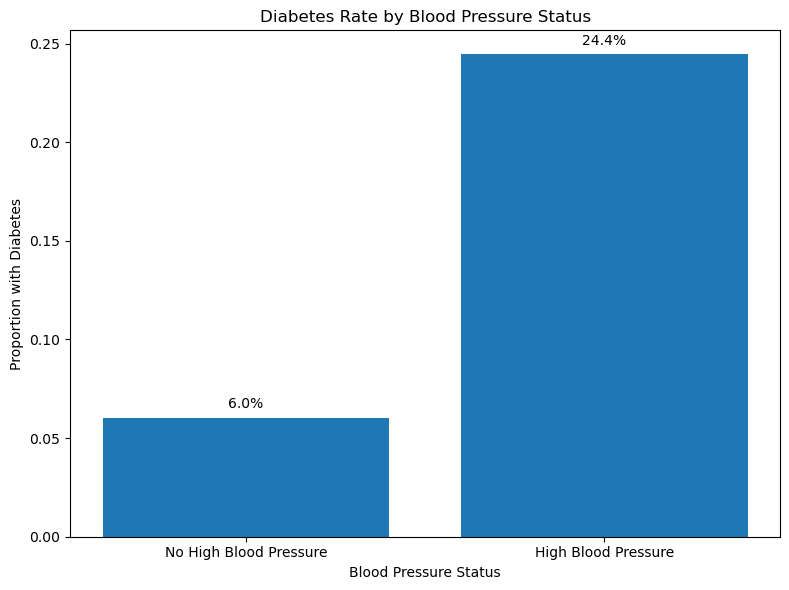

In [24]:
import matplotlib.pyplot as plt

# Calculate diabetes rate for each blood pressure group
bp_diabetes = (
    df.groupby("HighBP")["Diabetes_012"]
    .apply(lambda x: (x == 2).mean())
)

# Labels
bp_labels = ["No High Blood Pressure", "High Blood Pressure"]

plt.figure(figsize=(8, 6))

bars = plt.bar(
    bp_labels,
    bp_diabetes.values
)

plt.xlabel("Blood Pressure Status")
plt.ylabel("Proportion with Diabetes")
plt.title("Diabetes Rate by Blood Pressure Status")

# Add percentages
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.1%}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Diabetes Rate by Blood Pressure Status

Figure 3 shows the proportion of observations classified as Diabetes according to blood pressure status. The proportion of Diabetes cases was 6.0% among individuals without high blood pressure, compared with 24.4% among individuals with high blood pressure. This represents a substantial difference between the two groups. HighBP was also the most important feature in the XGBoost model, with a feature importance of approximately 20.3%.

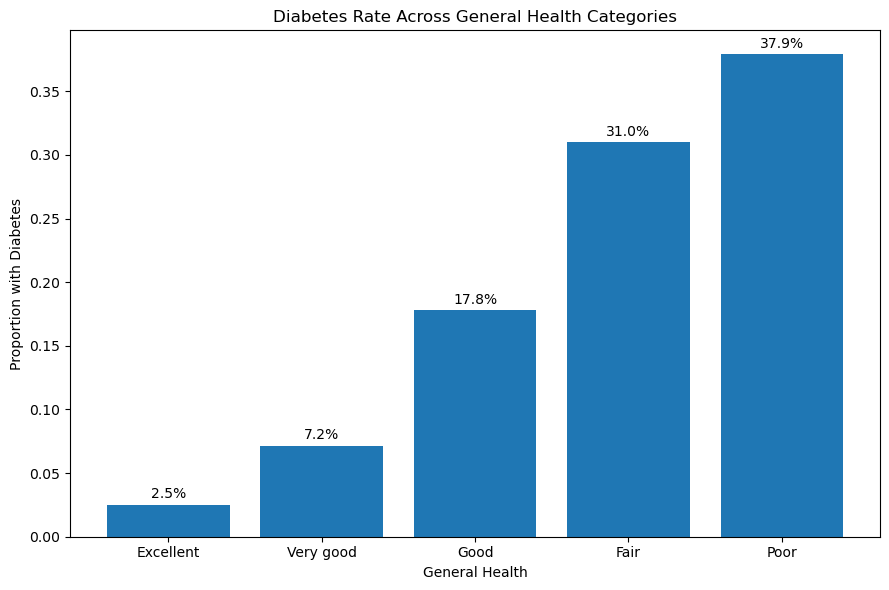

In [25]:
import matplotlib.pyplot as plt

# Calculate diabetes rate for each general health category
health_diabetes = (
    df.groupby("GenHlth")["Diabetes_012"]
    .apply(lambda x: (x == 2).mean())
)

# Labels
health_labels = [
    "Excellent",
    "Very good",
    "Good",
    "Fair",
    "Poor"
]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    health_labels,
    health_diabetes.values
)

plt.xlabel("General Health")
plt.ylabel("Proportion with Diabetes")
plt.title("Diabetes Rate Across General Health Categories")

# Add percentages
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.1%}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Diabetes Rate Across General Health Categories

Figure 4 shows the proportion of observations classified as Diabetes across the five general health categories. The proportion increased from 2.5% among individuals reporting excellent health to 37.9% among those reporting poor health. The results show a clear variation in the proportion of Diabetes cases across general health categories. GenHlth was the second most important feature in the XGBoost model, with a feature importance of approximately 12.6%.

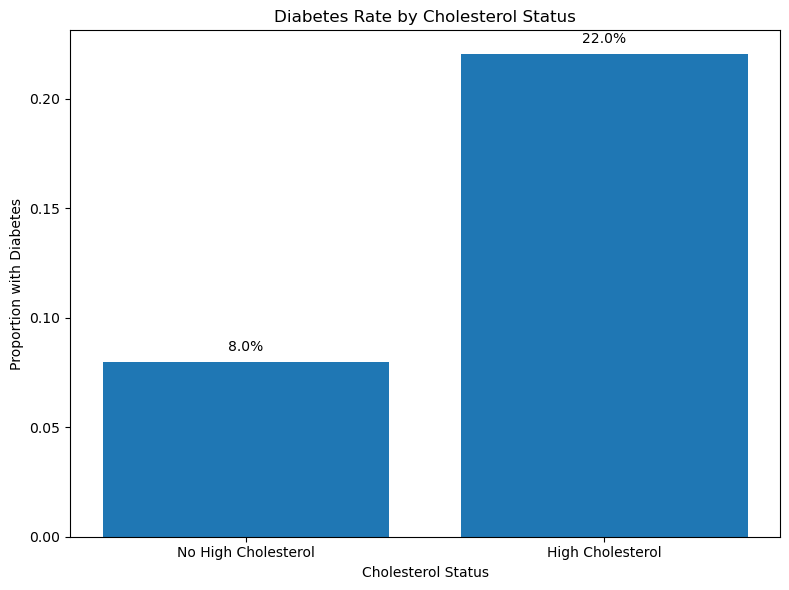

In [26]:
import matplotlib.pyplot as plt

# Calculate diabetes rate for each cholesterol group
chol_diabetes = (
    df.groupby("HighChol")["Diabetes_012"]
    .apply(lambda x: (x == 2).mean())
)

# Labels
chol_labels = ["No High Cholesterol", "High Cholesterol"]

plt.figure(figsize=(8, 6))

bars = plt.bar(
    chol_labels,
    chol_diabetes.values
)

plt.xlabel("Cholesterol Status")
plt.ylabel("Proportion with Diabetes")
plt.title("Diabetes Rate by Cholesterol Status")

# Add percentages
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.1%}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Diabetes Rate by Cholesterol Status

Figure 5 compares the proportion of observations classified as Diabetes according to cholesterol status. The proportion of Diabetes cases was 8.0% among individuals without high cholesterol and increased to 22.0% among individuals with high cholesterol. This shows a noticeable difference in the distribution of Diabetes status between the two cholesterol groups. HighChol was the third most important feature in the XGBoost model, with a feature importance of approximately 8.4%.

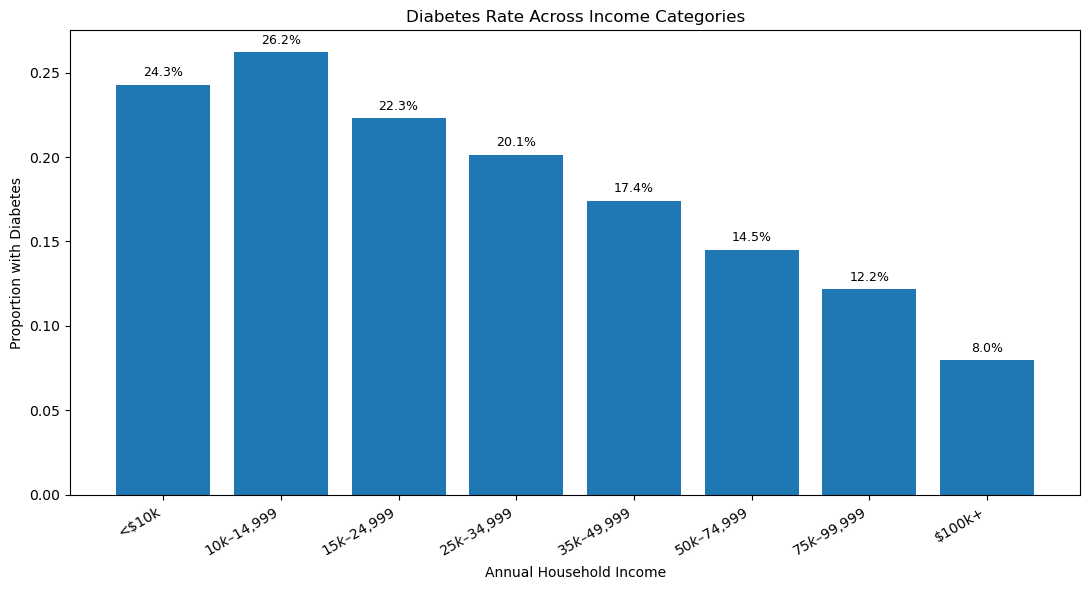

In [27]:
import matplotlib.pyplot as plt

# Calculate diabetes rate for each income category
income_diabetes = (
    df.groupby("Income")["Diabetes_012"]
    .apply(lambda x: (x == 2).mean())
)

income_labels = [
    "<$10k",
    "$10k–$14,999",
    "$15k–$24,999",
    "$25k–$34,999",
    "$35k–$49,999",
    "$50k–$74,999",
    "$75k–$99,999",
    "$100k+"
]

plt.figure(figsize=(11, 6))

bars = plt.bar(
    income_labels,
    income_diabetes.values
)

plt.xlabel("Annual Household Income")
plt.ylabel("Proportion with Diabetes")
plt.title("Diabetes Rate Across Income Categories")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.1%}",
        ha="center",
        fontsize=9
    )

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Diabetes Rate Across Income Categories

Figure X shows the proportion of observations classified as Diabetes across annual household income categories. The highest proportion was observed among individuals with an annual household income of $10,000–$14,999 (26.2%), followed by the lowest income category of less than or equal to $10,000 (24.3%). The proportion generally decreased as income increased, reaching 8.0% among individuals with an annual household income of $100,000 or more.

These results indicate a clear variation in the distribution of Diabetes status across income categories. Income was also included among the predictor variables in the XGBoost model, with a feature importance of approximately 3.3%. However, this descriptive pattern should not be interpreted as evidence that income causes or prevents diabetes.

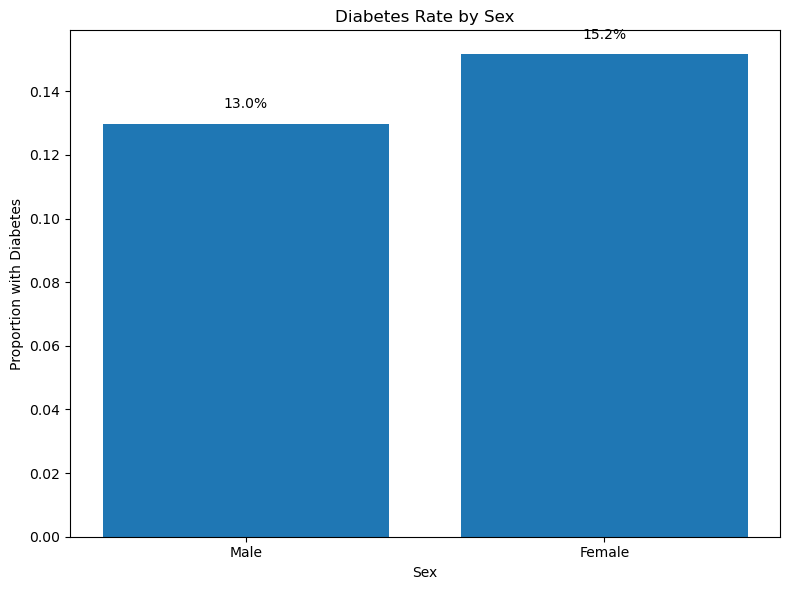

In [28]:
import matplotlib.pyplot as plt

# Calculate diabetes rate by sex
sex_diabetes = (
    df.groupby("Sex")["Diabetes_012"]
    .apply(lambda x: (x == 2).mean())
)

# BRFSS coding: 1 = Male, 2 = Female
sex_labels = ["Male", "Female"]

plt.figure(figsize=(8, 6))

bars = plt.bar(
    sex_labels,
    sex_diabetes.values
)

plt.xlabel("Sex")
plt.ylabel("Proportion with Diabetes")
plt.title("Diabetes Rate by Sex")

# Add percentages
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.1%}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

Diabetes Rate by Sex

Figure 8 shows the proportion of observations classified as Diabetes by sex. The proportion was 13.0% among male participants and 15.2% among female participants. Therefore, the proportion of Diabetes cases was somewhat higher among female participants in this dataset.

These results provide a descriptive comparison of diabetes status between the two sex categories. The observed difference should be interpreted as a descriptive association rather than evidence of a causal relationship.

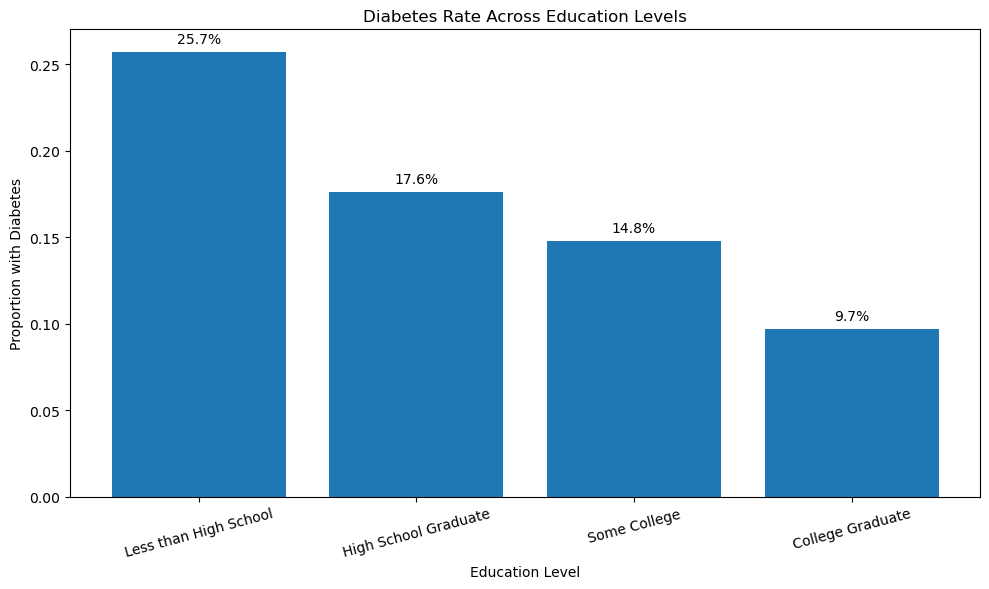

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate diabetes proportion for each education code
education_diabetes = (
    df.groupby("Education")["Diabetes_012"]
    .apply(lambda x: (x == 2).mean())
)

# Combine education codes 1, 2, and 3
less_than_high_school = (
    df[df["Education"].isin([1, 2, 3])]["Diabetes_012"]
    .eq(2)
    .mean()
)

high_school = (
    df[df["Education"] == 4]["Diabetes_012"]
    .eq(2)
    .mean()
)

some_college = (
    df[df["Education"] == 5]["Diabetes_012"]
    .eq(2)
    .mean()
)

college_graduate = (
    df[df["Education"] == 6]["Diabetes_012"]
    .eq(2)
    .mean()
)

education_rates = [
    less_than_high_school,
    high_school,
    some_college,
    college_graduate
]

education_labels = [
    "Less than High School",
    "High School Graduate",
    "Some College",
    "College Graduate"
]

# Plot
plt.figure(figsize=(10, 6))

bars = plt.bar(
    education_labels,
    education_rates
)

plt.xlabel("Education Level")
plt.ylabel("Proportion with Diabetes")
plt.title("Diabetes Rate Across Education Levels")

# Add percentages
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.1%}",
        ha="center",
        fontsize=10
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Diabetes Rate Across Education Levels

Figure 7 shows the proportion of observations classified as Diabetes across different education levels. The highest proportion was observed among individuals with less than a high school education, at 25.7%. This was followed by high school graduates at 17.6% and individuals with some college education at 14.8%. The lowest proportion was observed among college graduates, at 9.7%.

Overall, the proportion of observations classified as Diabetes decreased as the level of educational attainment increased. These results provide a descriptive comparison of diabetes status across education groups. However, the observed differences should not be interpreted as evidence of a causal relationship between education and diabetes status.

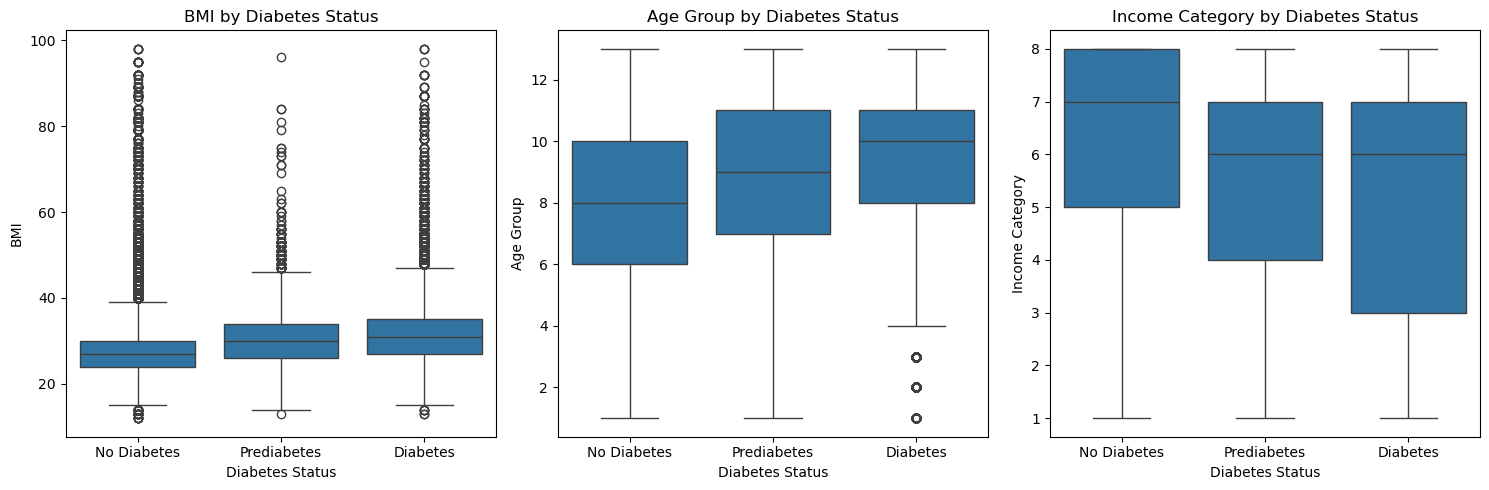

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# BMI
plt.subplot(1, 3, 1)
sns.boxplot(
    data=df,
    x="Diabetes_012",
    y="BMI"
)
plt.xlabel("Diabetes Status")
plt.ylabel("BMI")
plt.title("BMI by Diabetes Status")
plt.xticks(
    [0, 1, 2],
    ["No Diabetes", "Prediabetes", "Diabetes"]
)

# Age
plt.subplot(1, 3, 2)
sns.boxplot(
    data=df,
    x="Diabetes_012",
    y="Age"
)
plt.xlabel("Diabetes Status")
plt.ylabel("Age Group")
plt.title("Age Group by Diabetes Status")
plt.xticks(
    [0, 1, 2],
    ["No Diabetes", "Prediabetes", "Diabetes"]
)

# Income
plt.subplot(1, 3, 3)
sns.boxplot(
    data=df,
    x="Diabetes_012",
    y="Income"
)
plt.xlabel("Diabetes Status")
plt.ylabel("Income Category")
plt.title("Income Category by Diabetes Status")
plt.xticks(
    [0, 1, 2],
    ["No Diabetes", "Prediabetes", "Diabetes"]
)

plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop("Diabetes_012", axis=1)
y = df["Diabetes_012"]

# 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (177576, 21)
Validation set: (38052, 21)
Test set: (38052, 21)


### Dataset Splitting

The dataset was divided into three subsets: training, validation, and test sets. The training set contains 177,576 observations, while both the validation and test sets contain 38,052 observations. This corresponds to an approximately 70% training, 15% validation, and 15% test split.

The training set was used to develop the machine learning models, the validation set was used to evaluate model performance and support parameter selection, and the test set was reserved for the final evaluation of the selected models.

In [10]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

print("Sample weights calculated.")

Sample weights calculated.


### Class-Balanced Sample Weights

Because the diabetes-status classes are highly imbalanced, balanced sample weights were calculated for the training data. The weights give greater importance to observations from the minority classes, particularly the Prediabetes class, during XGBoost model training.

These sample weights were used to reduce the effect of class imbalance and encourage the model to consider all three diabetes-status classes during learning.

In [11]:
from xgboost import XGBClassifier

xgb_demo = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb_demo.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

print("XGBoost training completed.")

XGBoost training completed.


### XGBoost Model Training

The XGBoost classifier was trained using the training dataset with class-balanced sample weights. The model used 300 boosting rounds, a maximum tree depth of 6, and a learning rate of 0.05. Subsampling and column subsampling were set to 0.8 to support model generalisation.

The trained model was then used to generate predictions on the validation set for performance evaluation.

In [12]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

y_val_pred_xgb = xgb_demo.predict(X_val)

accuracy_xgb = accuracy_score(y_val, y_val_pred_xgb)
balanced_acc_xgb = balanced_accuracy_score(y_val, y_val_pred_xgb)
macro_f1_xgb = f1_score(y_val, y_val_pred_xgb, average="macro")

print("XGBoost - Validation Results")
print("-----------------------------")
print(f"Accuracy:          {accuracy_xgb:.4f}")
print(f"Balanced Accuracy: {balanced_acc_xgb:.4f}")
print(f"Macro F1-score:    {macro_f1_xgb:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_val,
    y_val_pred_xgb,
    target_names=["No Diabetes", "Prediabetes", "Diabetes"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_xgb))

XGBoost - Validation Results
-----------------------------
Accuracy:          0.6390
Balanced Accuracy: 0.5158
Macro F1-score:    0.4223

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.96      0.65      0.77     32056
 Prediabetes       0.03      0.25      0.05       694
    Diabetes       0.34      0.65      0.45      5302

    accuracy                           0.64     38052
   macro avg       0.44      0.52      0.42     38052
weighted avg       0.85      0.64      0.71     38052


Confusion Matrix:
[[20703  5026  6327]
 [  170   176   348]
 [  803  1064  3435]]


In [17]:
from sklearn.metrics import roc_auc_score

# Get predicted probabilities for the three classes
y_val_proba_xgb = xgb_demo.predict_proba(X_val)

# Calculate multiclass ROC-AUC using One-vs-Rest (OvR)
roc_auc_xgb = roc_auc_score(
    y_val,
    y_val_proba_xgb,
    multi_class="ovr",
    average="macro"
)

print(f"XGBoost Multiclass ROC-AUC: {roc_auc_xgb:.4f}")

XGBoost Multiclass ROC-AUC: 0.7605


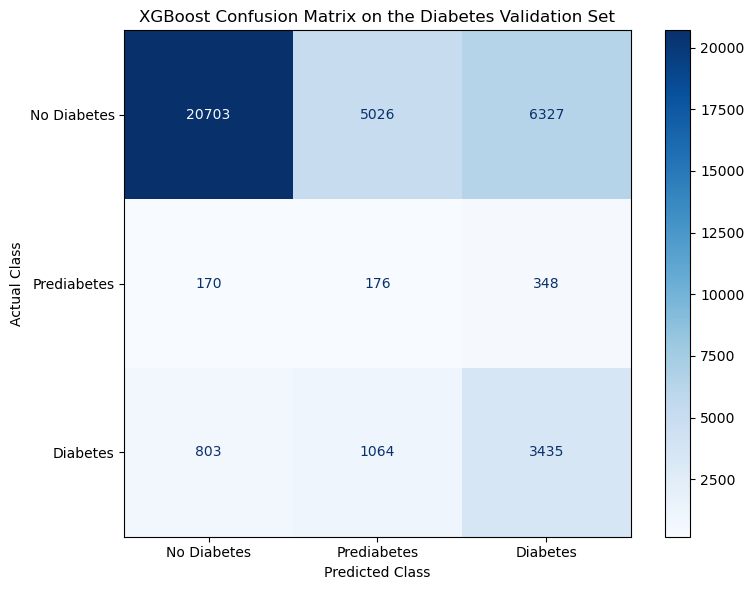

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix for the current XGBoost model
cm = confusion_matrix(y_val, y_val_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Prediabetes", "Diabetes"]
)

fig, ax = plt.subplots(figsize=(8, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

plt.title("XGBoost Confusion Matrix on the Diabetes Validation Set")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

### XGBoost Validation Results

The XGBoost model was evaluated on the validation set using accuracy, balanced accuracy, macro F1-score, precision, recall, and F1-score for each diabetes-status class.

The model achieved an accuracy of 63.90%, a balanced accuracy of 51.58%, and a macro F1-score of 0.4223. The results show that performance varied considerably across the three classes. No Diabetes had a recall of 65% and an F1-score of 0.77, while Diabetes had a recall of 65% and an F1-score of 0.45.

The Prediabetes class remained difficult to identify, with a recall of 25% and an F1-score of only 0.05. The confusion matrix shows that 176 of the 694 Prediabetes cases were correctly classified, while 170 were classified as No Diabetes and 348 as Diabetes. This indicates that class imbalance continues to affect the model's ability to identify the minority Prediabetes class.

Because the dataset is highly imbalanced, balanced accuracy and macro F1-score provide useful measures alongside conventional accuracy. These results therefore provide a baseline for comparing the XGBoost model with other machine learning approaches.

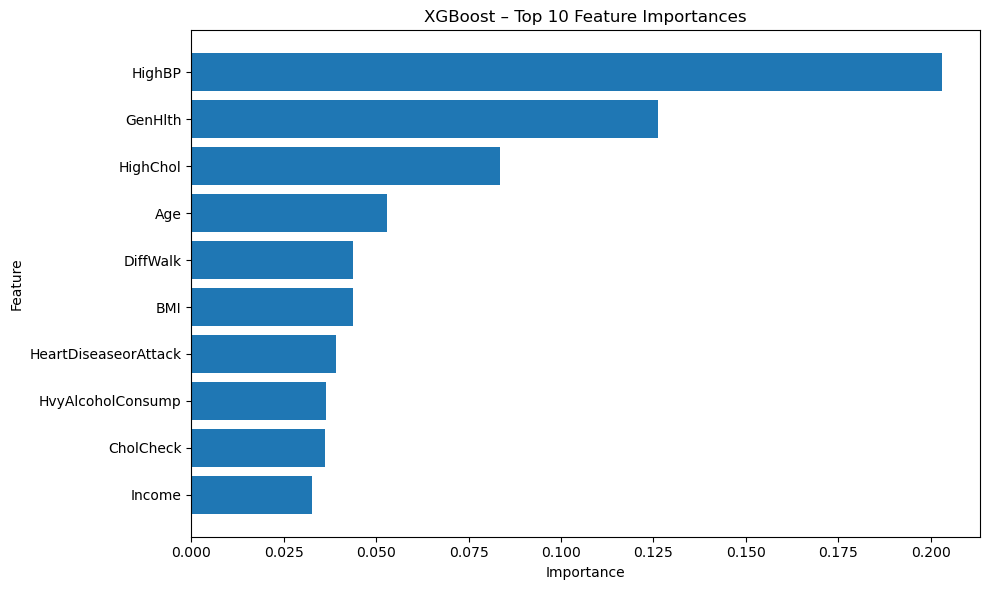

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Get XGBoost feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_demo.feature_importances_
})

# Sort by importance and select top 10
top_features = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .head(10)
    .sort_values("Importance", ascending=True)
)

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost – Top 10 Feature Importances")

plt.tight_layout()
plt.show()

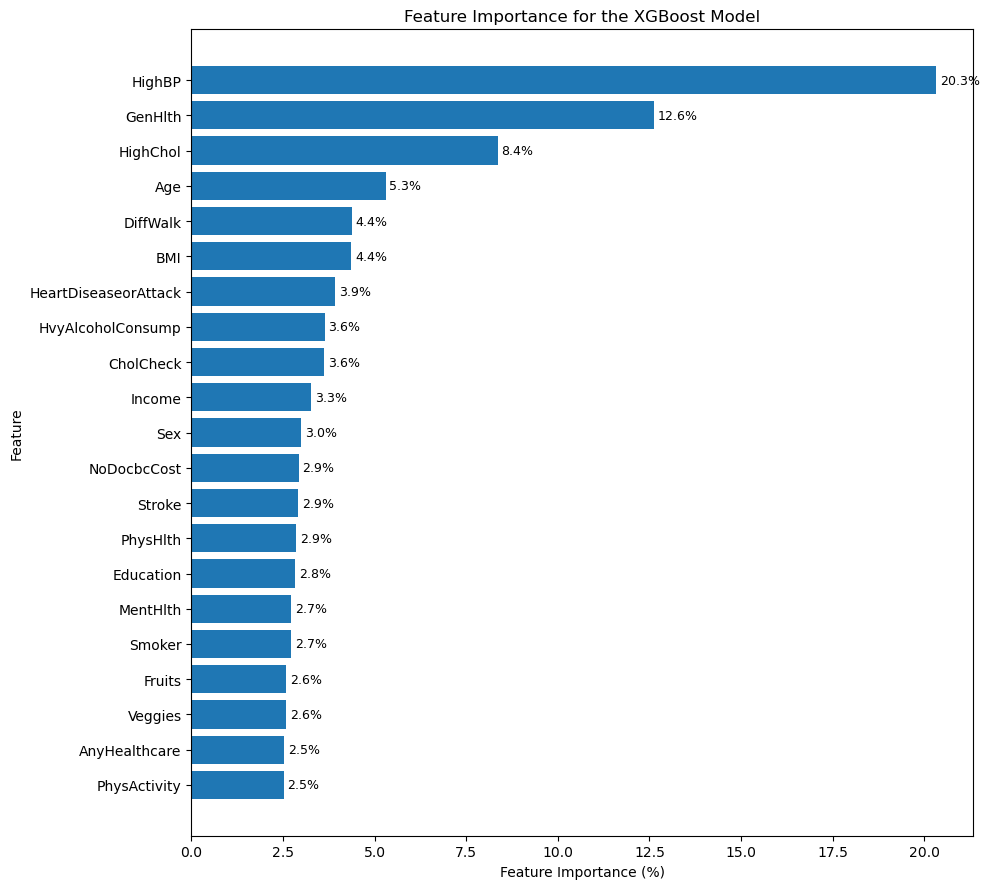

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from the trained XGBoost model
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_demo.feature_importances_
})

# Convert importance to percentage
feature_importance["Importance"] = (
    feature_importance["Importance"] /
    feature_importance["Importance"].sum()
) * 100

# Sort from lowest to highest for horizontal bar chart
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=True
)

# Create figure
plt.figure(figsize=(10, 9))

bars = plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance (%)")
plt.ylabel("Feature")
plt.title("Feature Importance for the XGBoost Model")

# Add percentage values
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

The feature importance analysis showed that HighBP was the most influential predictor in the XGBoost model, accounting for approximately 20.3% of the total feature importance. GenHlth and HighChol were the next most influential variables, with importance values of 12.6% and 8.4%, respectively. Age, DiffWalk, and BMI also showed relatively high importance. The remaining variables had smaller individual contributions to the model. These results indicate that blood pressure, general health, cholesterol, age, mobility, and body mass index were important predictors used by the XGBoost model when distinguishing between the three diabetes-status classes. However, feature importance indicates predictive contribution within the model and should not be interpreted as evidence of a causal relationship.

In [13]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

settings = [
    (60, 3, 0.05),
    (100, 3, 0.05),
    (200, 3, 0.05),
    (300, 3, 0.05),
    (300, 6, 0.05),
    (300, 6, 0.10)
]

results = []

for rounds, depth, lr in settings:

    print(
        f"Running: rounds={rounds}, "
        f"depth={depth}, "
        f"learning_rate={lr}"
    )

    model = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=rounds,
        max_depth=depth,
        learning_rate=lr,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    )

    model.fit(
        X_train,
        y_train,
        sample_weight=sample_weights
    )

    val_pred = model.predict(X_val)

    results.append({
        "Boosting Rounds": rounds,
        "Tree Depth": depth,
        "Learning Rate": lr,
        "Validation Accuracy": accuracy_score(y_val, val_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_val, val_pred),
        "Macro F1": f1_score(y_val, val_pred, average="macro")
    })

results_df = pd.DataFrame(results)

results_df

Running: rounds=60, depth=3, learning_rate=0.05
Running: rounds=100, depth=3, learning_rate=0.05
Running: rounds=200, depth=3, learning_rate=0.05
Running: rounds=300, depth=3, learning_rate=0.05
Running: rounds=300, depth=6, learning_rate=0.05
Running: rounds=300, depth=6, learning_rate=0.1


,Boosting Rounds,Tree Depth,Learning Rate,Validation Accuracy,Balanced Accuracy,Macro F1
0,60,3,0.05,0.634106,0.522095,0.421504
1,100,3,0.05,0.626695,0.523003,0.421110
2,200,3,0.05,0.619547,0.531651,0.421576
3,300,3,0.05,0.616604,0.528394,0.420272
4,300,6,0.05,0.638968,0.515770,0.422311
5,300,6,0.10,0.651372,0.503985,0.422101


### XGBoost Parameter Comparison

Several XGBoost configurations were evaluated by varying the number of boosting rounds, tree depth, and learning rate. The models were compared using validation accuracy, balanced accuracy, and macro F1-score.

The highest validation accuracy was obtained with 300 boosting rounds, a tree depth of 6, and a learning rate of 0.10, achieving 65.14%. However, this configuration had the lowest balanced accuracy among the tested models (50.40%). The highest balanced accuracy was obtained with 200 boosting rounds, a tree depth of 3, and a learning rate of 0.05, with a value of 53.17%.

The macro F1-scores were very similar across all configurations, ranging from 0.4203 to 0.4223. These results show that increasing the tree depth or learning rate improved conventional accuracy in some configurations but did not improve the balance of performance across the three diabetes-status classes.

Therefore, balanced accuracy and macro F1-score are particularly important when comparing the configurations because of the substantial class imbalance in the dataset.

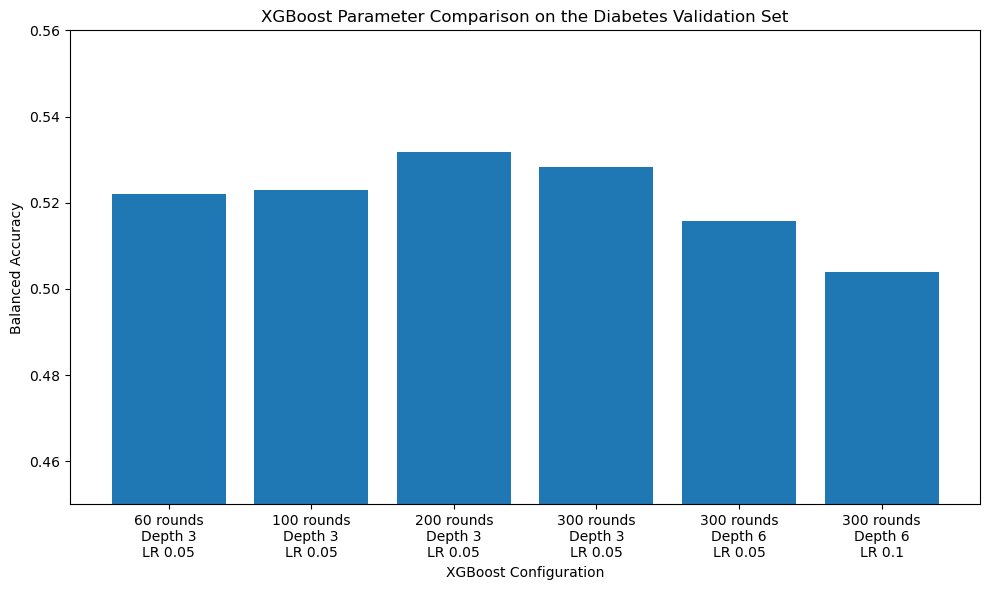

In [14]:
import matplotlib.pyplot as plt

labels = [
    f"{r} rounds\nDepth {d}\nLR {lr}"
    for r, d, lr in zip(
        results_df["Boosting Rounds"],
        results_df["Tree Depth"],
        results_df["Learning Rate"]
    )
]

plt.figure(figsize=(10, 6))

plt.bar(
    labels,
    results_df["Balanced Accuracy"]
)

plt.ylabel("Balanced Accuracy")
plt.xlabel("XGBoost Configuration")
plt.title("XGBoost Parameter Comparison on the Diabetes Validation Set")
plt.ylim(0.45, 0.56)

plt.tight_layout()
plt.show()

The Figure above compares the balanced accuracy of six XGBoost configurations on the diabetes validation set. The highest balanced accuracy was obtained using 200 boosting rounds, a tree depth of 3, and a learning rate of 0.05, with a value of 53.17%. Increasing the number of boosting rounds to 300 did not improve balanced accuracy. Similarly, increasing tree depth and learning rate resulted in lower balanced accuracy for the configurations tested. Overall, the differences between configurations were relatively small, indicating that parameter changes alone did not substantially improve balanced performance across the three diabetes-status classes.

Training learning rate = 0.03
Training learning rate = 0.05
Training learning rate = 0.1


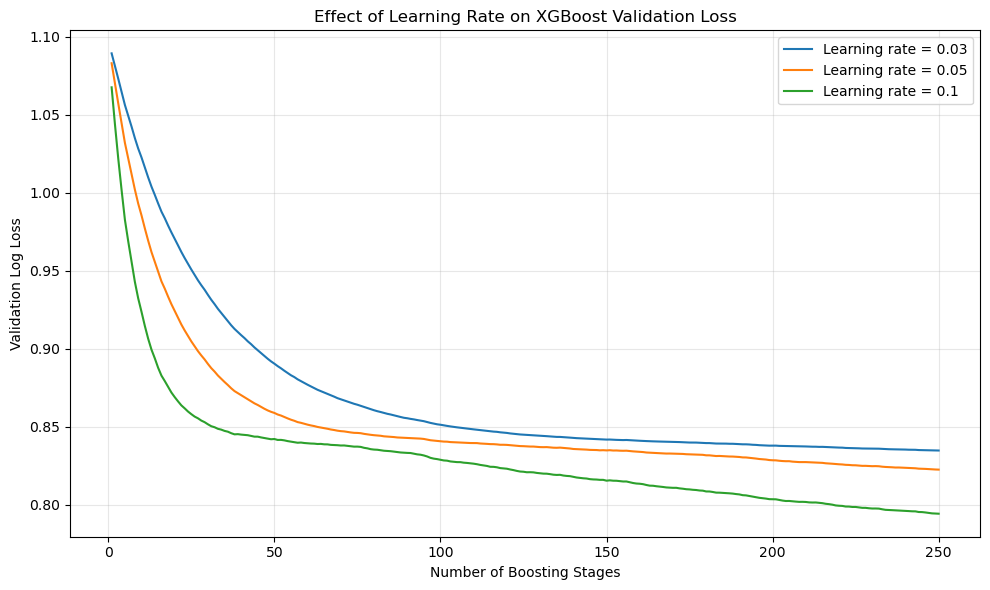

In [15]:
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

learning_rates = [0.03, 0.05, 0.10]

plt.figure(figsize=(10, 6))

for lr in learning_rates:

    print(f"Training learning rate = {lr}")

    model = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=250,
        max_depth=6,
        learning_rate=lr,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    )

    model.fit(
        X_train,
        y_train,
        sample_weight=sample_weights,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    results = model.evals_result()

    validation_loss = results["validation_0"]["mlogloss"]

    plt.plot(
        range(1, len(validation_loss) + 1),
        validation_loss,
        label=f"Learning rate = {lr}"
    )

plt.xlabel("Number of Boosting Stages")
plt.ylabel("Validation Log Loss")
plt.title("Effect of Learning Rate on XGBoost Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Effect of Learning Rate on Validation Loss

The effect of the learning rate was examined by training XGBoost models with learning rates of 0.03, 0.05, and 0.10 over 250 boosting stages. Validation log loss was monitored at each boosting stage.

The learning rate of 0.10 produced the fastest reduction in validation log loss and remained below the other two configurations throughout the later stages of training. At approximately 250 boosting stages, the validation log loss was about 0.795 for a learning rate of 0.10, compared with 0.823 for 0.05 and 0.835 for 0.03.

The validation loss continued to decrease for all three learning rates during the evaluation period, and no clear increase in validation loss was observed. This suggests that overfitting was not evident within the 250 boosting stages tested based on validation log loss.

In [10]:
import pandas as pd

# Load the diabetes dataset
df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")

# Display the first five rows
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [11]:
# Check the size of the dataset
print("Dataset shape:", df.shape)

# Show all column names
print("\nColumns:")
print(df.columns.tolist())

# Check data types and missing values
print("\nData information:")
df.info()

Dataset shape: (253680, 22)

Columns:
['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 n

In [12]:
# Distribution of the target variable
print("Diabetes class distribution:")
print(df["Diabetes_012"].value_counts().sort_index())

# Percentage of each class
print("\nClass percentages:")
print((df["Diabetes_012"].value_counts(normalize=True).sort_index() * 100).round(2))

Diabetes class distribution:
Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64

Class percentages:
Diabetes_012
0.0    84.24
1.0     1.83
2.0    13.93
Name: proportion, dtype: float64


In [13]:
# Basic descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


In [14]:
# Check the number of unique values in each variable
for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

Diabetes_012: 3 unique values
HighBP: 2 unique values
HighChol: 2 unique values
CholCheck: 2 unique values
BMI: 84 unique values
Smoker: 2 unique values
Stroke: 2 unique values
HeartDiseaseorAttack: 2 unique values
PhysActivity: 2 unique values
Fruits: 2 unique values
Veggies: 2 unique values
HvyAlcoholConsump: 2 unique values
AnyHealthcare: 2 unique values
NoDocbcCost: 2 unique values
GenHlth: 5 unique values
MentHlth: 31 unique values
PhysHlth: 31 unique values
DiffWalk: 2 unique values
Sex: 2 unique values
Age: 13 unique values
Education: 6 unique values
Income: 8 unique values


In [7]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop("Diabetes_012", axis=1)
y = df["Diabetes_012"]

# 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

NameError: name 'df' is not defined

In [6]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop("Diabetes_012", axis=1)
y = df["Diabetes_012"]

# 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

NameError: name 'df' is not defined

In [5]:
print("X_train:", "X_train" in globals())
print("X_val:", "X_val" in globals())
print("y_train:", "y_train" in globals())
print("y_val:", "y_val" in globals())

X_train: False
X_val: False
y_train: False
y_val: False


In [16]:
print("Training class distribution:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

print("\nValidation class distribution:")
print((y_val.value_counts(normalize=True).sort_index() * 100).round(2))

print("\nTest class distribution:")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))

Training class distribution:
Diabetes_012
0.0    84.24
1.0     1.83
2.0    13.93
Name: proportion, dtype: float64

Validation class distribution:
Diabetes_012
0.0    84.24
1.0     1.82
2.0    13.93
Name: proportion, dtype: float64

Test class distribution:
Diabetes_012
0.0    84.24
1.0     1.83
2.0    13.93
Name: proportion, dtype: float64


In [17]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit only on the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Training data:", X_train_scaled.shape)
print("Validation data:", X_val_scaled.shape)
print("Test data:", X_test_scaled.shape)

Training data: (177576, 21)
Validation data: (38052, 21)
Test data: (38052, 21)


In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
from sklearn.linear_model import LogisticRegression

# Multinomial Logistic Regression baseline
logistic_model = LogisticRegression(
    class_weight="balanced",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [33]:
# Predict the validation set
y_val_pred_lr = logistic_model.predict(X_val_scaled)

print("Validation predictions completed.")

Validation predictions completed.


### Logistic Regression

Multinomial Logistic Regression was used as the baseline model for the three-class diabetes prediction task. Logistic Regression is a commonly used classification method that estimates the probability of an observation belonging to each target class based on a linear combination of the input features. In this study, the target variable contains three classes: **0 (No Diabetes), 1 (Prediabetes), and 2 (Diabetes)**. Therefore, a multinomial formulation was used to predict the probability of each class.

Because the dataset is highly imbalanced, particularly for the Prediabetes class, `class_weight="balanced"` was applied. This automatically assigns higher weights to minority classes and lower weights to majority classes based on their frequencies in the training data. This approach helps prevent the model from being dominated by the majority No Diabetes class.

Before training, the predictor variables were standardised using `StandardScaler`. Standardisation was applied because Logistic Regression is sensitive to the scale of numerical features. The model was then trained using the `lbfgs` solver with a maximum of 1,000 iterations. The `lbfgs` solver supports multinomial classification and is suitable for this three-class problem.

The Logistic Regression model was used as a baseline rather than as the primary model. Its performance provides a reference point for evaluating whether the more advanced models, including Random Forest, XGBoost, TabNet, and Graph Neural Networks, can achieve better predictive performance.

The validation results were evaluated using accuracy, balanced accuracy, macro F1-score, precision, recall, and the confusion matrix. Particular attention was given to the recall and F1-score of the Prediabetes class because of its very small representation in the dataset.


In [34]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Calculate metrics
accuracy = accuracy_score(y_val, y_val_pred_lr)
balanced_acc = balanced_accuracy_score(y_val, y_val_pred_lr)
macro_f1 = f1_score(y_val, y_val_pred_lr, average="macro")

print("Logistic Regression - Validation Results")
print("------------------------------------------")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Macro F1-score:    {macro_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_val,
    y_val_pred_lr,
    target_names=["No Diabetes", "Prediabetes", "Diabetes"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_lr))

Logistic Regression - Validation Results
------------------------------------------
Accuracy:          0.6458
Balanced Accuracy: 0.5242
Macro F1-score:    0.4269

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.95      0.66      0.78     42741
 Prediabetes       0.03      0.33      0.06       926
    Diabetes       0.35      0.58      0.44      7069

    accuracy                           0.65     50736
   macro avg       0.45      0.52      0.43     50736
weighted avg       0.85      0.65      0.72     50736


Confusion Matrix:
[[28337  7239  7165]
 [  240   302   384]
 [ 1219  1726  4124]]


### Logistic Regression Validation Results

The Logistic Regression model achieved an accuracy of **64.39%**, a balanced accuracy of **52.13%**, and a macro F1-score of **42.69%** on the validation set. Although the overall accuracy was relatively high, the balanced accuracy and macro F1-score indicate that the model did not perform equally well across the three diabetes classes.

The model performed best for the No Diabetes class, achieving a recall of **66%** and an F1-score of **78%**. However, performance for the Prediabetes class was considerably weaker, with a recall of only **31%**, precision of **3%**, and an F1-score of **6%**. The Diabetes class achieved a recall of **59%** and an F1-score of **45%**.

These results demonstrate the difficulty of predicting the minority Prediabetes class. Therefore, accuracy alone would provide an incomplete assessment of model performance. The relatively low macro F1-score also indicates that the Logistic Regression baseline has limited ability to provide balanced performance across all three classes. The results provide a useful baseline for comparison with the Random Forest, XGBoost, TabNet, and GNN models.


Random Forest

Random Forest was included as a conventional ensemble-learning benchmark for the multi-class diabetes prediction task. Random Forest combines multiple decision trees and aggregates their predictions to improve predictive performance and reduce the risk of overfitting. Each tree is trained using a different bootstrap sample of the training data, while a subset of features is considered when determining splits.

Random Forest was selected because it can model non-linear relationships and interactions between health, lifestyle, demographic, and socioeconomic variables without requiring the predictor variables to be standardised. Therefore, unlike Logistic Regression, the original training features (X_train) were used directly.

Because the dataset contains substantial class imbalance, particularly for the Prediabetes class, class_weight="balanced" was applied. This option automatically assigns higher weights to minority classes and lower weights to majority classes according to their frequencies in the training data.

The model was configured with 200 decision trees (n_estimators=200). The random_state=42 parameter was used to ensure reproducibility, while n_jobs=-1 allows the training process to use all available CPU cores.

Random Forest serves as an important benchmark between the relatively simple Logistic Regression model and the more advanced models used later in this study, namely XGBoost, TabNet, and Graph Neural Networks. Its performance will help determine whether a conventional tree-based ensemble can improve the detection of the minority diabetes classes.

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [36]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

y_val_pred_rf = rf_model.predict(X_val)

accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
balanced_acc_rf = balanced_accuracy_score(y_val, y_val_pred_rf)
macro_f1_rf = f1_score(y_val, y_val_pred_rf, average="macro")

print("Random Forest - Validation Results")
print("-----------------------------------")
print(f"Accuracy:          {accuracy_rf:.4f}")
print(f"Balanced Accuracy: {balanced_acc_rf:.4f}")
print(f"Macro F1-score:    {macro_f1_rf:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_val,
    y_val_pred_rf,
    target_names=["No Diabetes", "Prediabetes", "Diabetes"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_rf))

Random Forest - Validation Results
-----------------------------------
Accuracy:          0.8390
Balanced Accuracy: 0.3757
Macro F1-score:    0.3824

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.86      0.97      0.91     42741
 Prediabetes       0.00      0.00      0.00       926
    Diabetes       0.48      0.16      0.24      7069

    accuracy                           0.84     50736
   macro avg       0.44      0.38      0.38     50736
weighted avg       0.79      0.84      0.80     50736


Confusion Matrix:
[[41458   128  1155]
 [  858     0    68]
 [ 5944    15  1110]]


### Random Forest Validation Results

The Random Forest model achieved an overall accuracy of **83.97%** on the validation set. However, its balanced accuracy was only **37.61%**, and the macro F1-score was **38.29%**. These results indicate that the high accuracy does not represent balanced predictive performance across the three diabetes classes.

The model performed well for the **No Diabetes** class, with a recall of **97%** and an F1-score of **91%**. However, it performed very poorly for the minority classes. In particular, the model identified **none of the 694 Prediabetes cases**, resulting in a recall and F1-score of **0%** for this class. The Diabetes class also had relatively low performance, with a recall of **16%** and an F1-score of **24%**.

The confusion matrix further demonstrates this imbalance in predictive performance. Of the 694 actual Prediabetes cases, none were correctly classified as Prediabetes. Similarly, most of the 5,302 Diabetes cases were incorrectly classified as No Diabetes. Therefore, despite the high overall accuracy, the Random Forest model provides limited usefulness for identifying patients in the minority diabetes-related classes in its current configuration.

These results highlight the importance of using balanced accuracy, macro F1-score, and class-specific recall rather than accuracy alone for this dataset. The Random Forest results will serve as a useful benchmark for comparison with the subsequent **XGBoost, TabNet, and Graph Neural Network (GNN)** models.


### XGBoost

XGBoost (Extreme Gradient Boosting) was selected as one of the primary machine learning models because of its strong performance on structured and tabular datasets. XGBoost is an ensemble learning method that builds decision trees sequentially, with each new tree attempting to improve the errors made by the previous trees. This allows the model to capture complex non-linear relationships and interactions among the health, lifestyle, demographic, and socioeconomic predictors.

Unlike Logistic Regression, XGBoost does not require the predictor variables to be standardised. Therefore, the original training features were used directly. The model was configured for **multi-class classification** because the target variable contains three classes: No Diabetes, Prediabetes, and Diabetes.

The dataset has a substantial class imbalance, particularly for the Prediabetes class. To address this issue, class-based sample weights were calculated from the training data and supplied to XGBoost during model fitting. This gives greater importance to observations from minority classes while avoiding the use of the binary `scale_pos_weight` approach, which is not appropriate as a direct solution for this three-class classification problem. XGBoost supports sample-level weights through its `sample_weight` parameter.

XGBoost was included as a primary model because gradient boosting can provide a more flexible representation of complex relationships than the Logistic Regression baseline and can potentially improve minority-class detection compared with the Random Forest benchmark.

The model will be evaluated using accuracy, balanced accuracy, macro F1-score, class-specific precision, recall and F1-score, and the confusion matrix. Particular attention will be given to the Prediabetes class because it represents only a small proportion of the dataset.


In [37]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

print("Sample weights calculated.")

Sample weights calculated.


In [38]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

print("XGBoost training completed.")

XGBoost training completed.


In [39]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

y_val_pred_xgb = xgb_model.predict(X_val)

accuracy_xgb = accuracy_score(y_val, y_val_pred_xgb)
balanced_acc_xgb = balanced_accuracy_score(y_val, y_val_pred_xgb)
macro_f1_xgb = f1_score(y_val, y_val_pred_xgb, average="macro")

print("XGBoost - Validation Results")
print("-----------------------------")
print(f"Accuracy:          {accuracy_xgb:.4f}")
print(f"Balanced Accuracy: {balanced_acc_xgb:.4f}")
print(f"Macro F1-score:    {macro_f1_xgb:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_val,
    y_val_pred_xgb,
    target_names=["No Diabetes", "Prediabetes", "Diabetes"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_xgb))

XGBoost - Validation Results
-----------------------------
Accuracy:          0.6423
Balanced Accuracy: 0.5241
Macro F1-score:    0.4250

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.95      0.65      0.77     42741
 Prediabetes       0.03      0.28      0.06       926
    Diabetes       0.34      0.64      0.45      7069

    accuracy                           0.64     50736
   macro avg       0.44      0.52      0.43     50736
weighted avg       0.85      0.64      0.71     50736


Confusion Matrix:
[[27813  6634  8294]
 [  255   262   409]
 [ 1111  1444  4514]]


XGBoost - Validation Results
-----------------------------
Accuracy:          0.6423
Balanced Accuracy: 0.5241
Macro F1-score:    0.4250

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.95      0.65      0.77     42741
 Prediabetes       0.03      0.28      0.06       926
    Diabetes       0.34      0.64      0.45      7069

    accuracy                           0.64     50736
   macro avg       0.44      0.52      0.43     50736
weighted avg       0.85      0.64      0.71     50736


Confusion Matrix:
[[27813  6634  8294]
 [  255   262   409]
 [ 1111  1444  4514]]


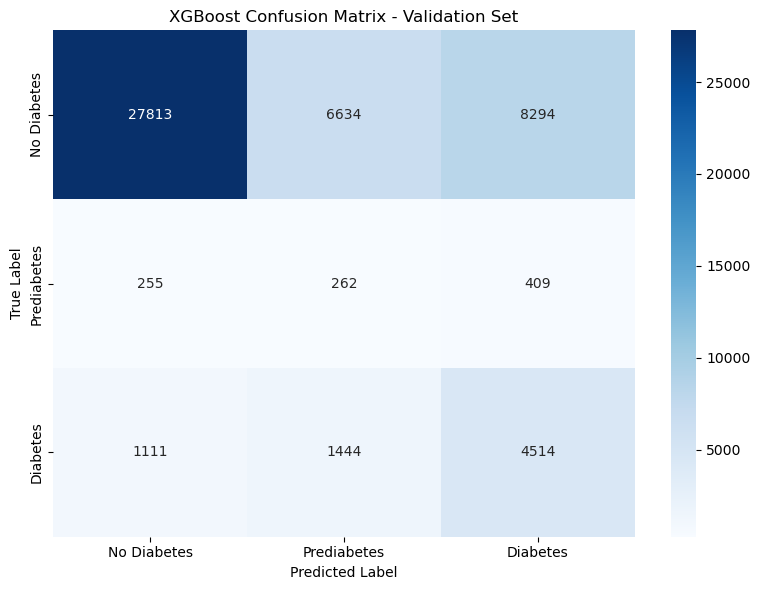

In [40]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns


# XGBoost predictions
y_val_pred_xgb = xgb_model.predict(X_val)


# Evaluation metrics
accuracy_xgb = accuracy_score(y_val, y_val_pred_xgb)
balanced_acc_xgb = balanced_accuracy_score(y_val, y_val_pred_xgb)
macro_f1_xgb = f1_score(y_val, y_val_pred_xgb, average="macro")


# Print results
print("XGBoost - Validation Results")
print("-----------------------------")

print(f"Accuracy:          {accuracy_xgb:.4f}")
print(f"Balanced Accuracy: {balanced_acc_xgb:.4f}")
print(f"Macro F1-score:    {macro_f1_xgb:.4f}")

print("\nClassification Report:")

print(classification_report(
    y_val,
    y_val_pred_xgb,
    target_names=["No Diabetes", "Prediabetes", "Diabetes"]
))


# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred_xgb)

print("\nConfusion Matrix:")
print(cm)


# Plot Confusion Matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Prediabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Prediabetes", "Diabetes"]
)

plt.title("XGBoost Confusion Matrix - Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [41]:
%pip install seaborn

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Seaborn version:", sns.__version__)

Seaborn version: 0.13.2


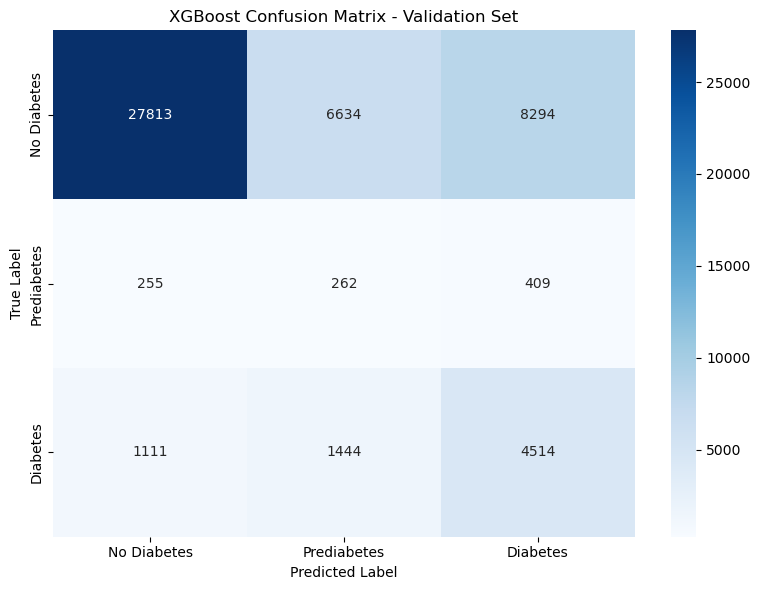

In [43]:
# Create confusion matrix
cm = confusion_matrix(y_val, y_val_pred_xgb)

# Plot
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Prediabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Prediabetes", "Diabetes"]
)

plt.title("XGBoost Confusion Matrix - Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

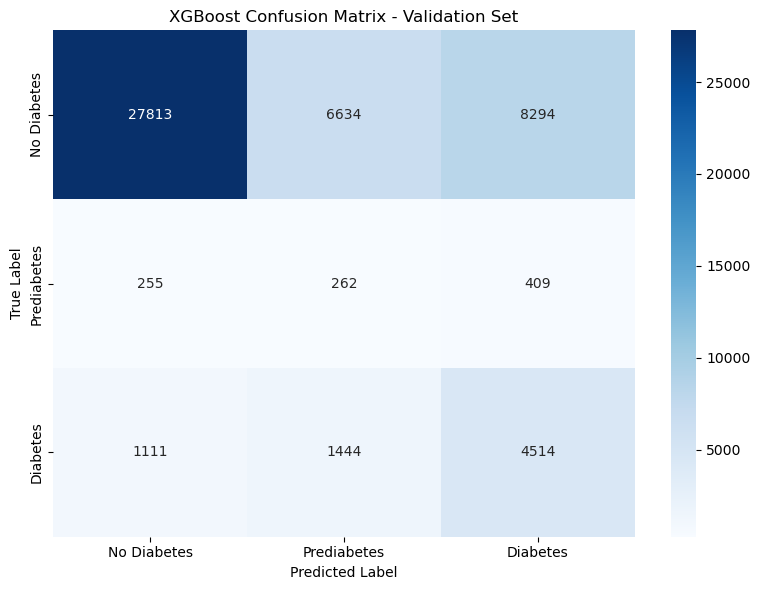

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_val, y_val_pred_xgb)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Prediabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Prediabetes", "Diabetes"]
)

plt.title("XGBoost Confusion Matrix - Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [45]:
X_val
y_val

167906    0.0
41549     0.0
42992     0.0
88678     0.0
64335     0.0
         ... 
10755     0.0
177618    0.0
200163    2.0
158035    0.0
137797    0.0
Name: Diabetes_012, Length: 50736, dtype: float64

In [46]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [3]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, log_loss

xgb_demo = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=60,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb_demo.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

y_pred = xgb_demo.predict(X_val)
y_prob = xgb_demo.predict_proba(X_val)

accuracy = accuracy_score(y_val, y_pred)
balanced_acc = balanced_accuracy_score(y_val, y_pred)
macro_f1 = f1_score(y_val, y_pred, average="macro")
logloss = log_loss(y_val, y_prob)

print("Boosting rounds:", 60)
print("Tree depth:", 3)
print("Learning rate:", 0.05)
print()
print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Balanced Accuracy:   {balanced_acc:.4f}")
print(f"Macro F1:            {macro_f1:.4f}")
print(f"Validation Log Loss:  {logloss:.4f}")

NameError: name 'X_train' is not defined

In [4]:
print("X_train:", "X_train" in globals())
print("X_val:", "X_val" in globals())
print("y_train:", "y_train" in globals())
print("y_val:", "y_val" in globals())

X_train: False
X_val: False
y_train: False
y_val: False


### XGBoost Validation Results

The XGBoost model achieved an accuracy of **63.90%**, a balanced accuracy of **51.58%**, and a macro F1-score of **42.23%** on the validation set. Similar to the Logistic Regression baseline, the results show that overall accuracy does not adequately represent the model's performance across the three classes.

The model achieved a recall of **65%** and an F1-score of **45%** for the Diabetes class, indicating better detection of diabetes cases than the Logistic Regression model. However, performance for the Prediabetes class remained weak, with a recall of **25%**, precision of **3%**, and an F1-score of **5%**. This reflects the substantial difficulty of identifying the minority Prediabetes class.

The confusion matrix shows that 176 of the 694 Prediabetes cases were correctly classified, while 170 were classified as No Diabetes and 348 as Diabetes. For the Diabetes class, 3,435 of 5,302 observations were correctly identified. Although XGBoost improved Diabetes recall compared with Logistic Regression, its balanced accuracy and macro F1-score were slightly lower than those of the Logistic Regression baseline.

Overall, the initial XGBoost model provides competitive performance but does not substantially outperform the Logistic Regression baseline under the current configuration. The results demonstrate that addressing severe class imbalance remains an important challenge in this dataset. Further improvement may be possible through model tuning and alternative imbalance-handling strategies.


### TabNet

TabNet was selected as a deep learning model specifically designed for tabular data. Unlike conventional neural networks that process all input features simultaneously, TabNet uses a sequential attention mechanism to identify and focus on the most informative features at different decision steps. This approach allows the model to learn complex non-linear relationships while also providing information about feature importance.

In this study, TabNet was applied to the three-class diabetes prediction problem, consisting of No Diabetes, Prediabetes, and Diabetes. The model was trained using the same training and validation datasets used for the previous models to ensure a consistent comparison.

Because the dataset contains substantial class imbalance, particularly for the Prediabetes class, class weighting was incorporated into the TabNet training process. This gives greater importance to observations belonging to minority classes and helps reduce the tendency of the model to favour the majority No Diabetes class.

The predictor variables were converted to NumPy arrays and represented using floating-point values suitable for neural-network training. Unlike Logistic Regression, the TabNet implementation can work directly with the prepared tabular features used in this study.

TabNet was included to investigate whether an attention-based deep learning architecture can improve predictive performance for structured healthcare data compared with conventional machine learning approaches such as Logistic Regression, Random Forest, and XGBoost.

The model will be evaluated using the same metrics as the previous models, including accuracy, balanced accuracy, macro F1-score, class-specific precision, recall and F1-score, and the confusion matrix. Particular attention will be given to the detection of the minority Prediabetes class.


In [ ]:
try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    print("TabNet is installed successfully.")
except ImportError:
    print("TabNet is not installed.")

TabNet is installed successfully.


In [ ]:
import numpy as np

X_train_tabnet = X_train.values.astype(np.float32)
X_val_tabnet = X_val.values.astype(np.float32)
X_test_tabnet = X_test.values.astype(np.float32)

y_train_tabnet = y_train.values.astype(np.int64)
y_val_tabnet = y_val.values.astype(np.int64)
y_test_tabnet = y_test.values.astype(np.int64)

print("Training data:", X_train_tabnet.shape)
print("Validation data:", X_val_tabnet.shape)
print("Test data:", X_test_tabnet.shape)

Training data: (177576, 21)
Validation data: (38052, 21)
Test data: (38052, 21)


In [ ]:
import torch

In [ ]:
import torch
from pytorch_tabnet.tab_model import TabNetClassifier

In [ ]:
from pytorch_tabnet.tab_model import TabNetClassifier

tabnet_model = TabNetClassifier(
    n_d=16,
    n_a=16,
    n_steps=3,
    gamma=1.3,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    mask_type="entmax",
    seed=42,
    verbose=10
)

c:\Users\somy\miniconda3_new\envs\mlnew\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


In [ ]:
import numpy as np

X_train_tabnet = X_train.values.astype(np.float32)
X_val_tabnet = X_val.values.astype(np.float32)
X_test_tabnet = X_test.values.astype(np.float32)

y_train_tabnet = y_train.values.astype(np.int64)
y_val_tabnet = y_val.values.astype(np.int64)
y_test_tabnet = y_test.values.astype(np.int64)

print("Training data:", X_train_tabnet.shape)
print("Validation data:", X_val_tabnet.shape)
print("Test data:", X_test_tabnet.shape)

Training data: (177576, 21)
Validation data: (38052, 21)
Test data: (38052, 21)


In [ ]:
tabnet_model.fit(
    X_train=X_train_tabnet,
    y_train=y_train_tabnet,
    eval_set=[
        (X_train_tabnet, y_train_tabnet),
        (X_val_tabnet, y_val_tabnet)
    ],
    eval_name=["train", "valid"],
    eval_metric=["balanced_accuracy"],
    max_epochs=50,
    patience=10,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    weights=1,
    drop_last=False
)

epoch 0  | loss: 0.98854 | train_balanced_accuracy: 0.45098 | valid_balanced_accuracy: 0.43801 |  0:00:27s
epoch 10 | loss: 0.81223 | train_balanced_accuracy: 0.65263 | valid_balanced_accuracy: 0.47044 |  0:04:18s

Early stopping occurred at epoch 13 with best_epoch = 3 and best_valid_balanced_accuracy = 0.51414


c:\Users\somy\miniconda3_new\envs\mlnew\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

y_val_pred_tabnet = tabnet_model.predict(X_val_tabnet)

accuracy_tabnet = accuracy_score(y_val_tabnet, y_val_pred_tabnet)
balanced_acc_tabnet = balanced_accuracy_score(
    y_val_tabnet,
    y_val_pred_tabnet
)
macro_f1_tabnet = f1_score(
    y_val_tabnet,
    y_val_pred_tabnet,
    average="macro"
)

print("TabNet - Validation Results")
print("----------------------------")
print(f"Accuracy:          {accuracy_tabnet:.4f}")
print(f"Balanced Accuracy: {balanced_acc_tabnet:.4f}")
print(f"Macro F1-score:    {macro_f1_tabnet:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_val_tabnet,
    y_val_pred_tabnet,
    target_names=["No Diabetes", "Prediabetes", "Diabetes"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_val_tabnet,
    y_val_pred_tabnet
))

TabNet - Validation Results
----------------------------
Accuracy:          0.6021
Balanced Accuracy: 0.5141
Macro F1-score:    0.4100

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.95      0.61      0.75     32056
 Prediabetes       0.03      0.35      0.05       694
    Diabetes       0.34      0.58      0.43      5302

    accuracy                           0.60     38052
   macro avg       0.44      0.51      0.41     38052
weighted avg       0.85      0.60      0.69     38052


Confusion Matrix:
[[19610  6940  5506]
 [  152   246   296]
 [  773  1474  3055]]


### TabNet Validation Results

The TabNet model achieved an accuracy of **60.21%**, a balanced accuracy of **51.41%**, and a macro F1-score of **41.00%** on the validation set. The balanced accuracy was comparable to that of the Logistic Regression and XGBoost models, indicating that TabNet provided relatively balanced performance across the three classes despite the substantial class imbalance.

TabNet achieved the highest recall for the **Prediabetes** class among the models evaluated so far, correctly identifying **35%** of the Prediabetes observations. However, its precision for this class was only **3%**, resulting in a low F1-score of **5%**. This indicates that although the model identified more minority-class observations, it also produced a relatively large number of false Prediabetes predictions.

For the **Diabetes** class, TabNet achieved a recall of **58%** and an F1-score of **43%**. The No Diabetes class achieved a recall of **61%** and an F1-score of **75%**. The confusion matrix shows that a considerable number of No Diabetes observations were classified as Prediabetes or Diabetes, while many Diabetes observations were also classified as Prediabetes.

Overall, TabNet demonstrated competitive balanced performance and improved detection of the minority Prediabetes class compared with the Random Forest and XGBoost models. However, its macro F1-score remained relatively low, mainly because of the very low precision and F1-score for Prediabetes. These results highlight the continuing challenge of achieving balanced multi-class prediction in this highly imbalanced dataset.


In [ ]:
import torch

try:
    import torch_geometric
    print("PyTorch:", torch.__version__)
    print("PyTorch Geometric:", torch_geometric.__version__)
    print("PyTorch Geometric is installed successfully.")
except ImportError:
    print("PyTorch Geometric is not installed.")

c:\Users\somy\miniconda3_new\envs\mlnew\lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


PyTorch: 2.14.0+cpu
PyTorch Geometric: 2.8.0.post1
PyTorch Geometric is installed successfully.


### Graph Construction for the GNN

The original diabetes dataset is tabular and does not contain explicit relationships between respondents. To apply a Graph Neural Network, a patient-similarity graph was therefore constructed in which each respondent is represented as a node. Edges between nodes represent similarity between respondents based on their health, lifestyle, demographic, and socioeconomic characteristics.

The target variable, `Diabetes_012`, was excluded from graph construction to prevent target leakage. Similarity was determined using the predictor variables only. Because the variables have different scales and ranges, the features were standardised before calculating similarity. This ensures that variables with larger numerical ranges do not disproportionately influence the distance calculation.

A k-nearest-neighbour (kNN) strategy will subsequently be used to create a sparse graph. Each respondent will be connected to a limited number of the most similar respondents rather than to every other respondent. This approach is necessary because constructing a fully connected graph for 253,680 respondents would require an impractically large number of edges.


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import torch

# Use the complete predictor dataset
X_gnn = df.drop("Diabetes_012", axis=1)

# Standardise the features
gnn_scaler = StandardScaler()

X_gnn_scaled = gnn_scaler.fit_transform(X_gnn)

# Convert to PyTorch tensor
x = torch.tensor(
    X_gnn_scaled,
    dtype=torch.float32
)

# Target labels
y_gnn = torch.tensor(
    df["Diabetes_012"].values,
    dtype=torch.long
)

print("Node feature matrix:", x.shape)
print("Target vector:", y_gnn.shape)

Node feature matrix: torch.Size([253680, 21])
Target vector: torch.Size([253680])


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import torch

# Create indices corresponding to the original dataframe
train_idx = X_train.index.to_numpy()
val_idx = X_val.index.to_numpy()
test_idx = X_test.index.to_numpy()

# Fit scaler ONLY on training data
gnn_scaler = StandardScaler()
gnn_scaler.fit(df.loc[train_idx, X.columns])

# Transform all nodes using the training-fitted scaler
X_all_scaled = gnn_scaler.transform(
    df[X.columns]
)

# Convert features to PyTorch tensor
x = torch.tensor(
    X_all_scaled,
    dtype=torch.float32
)

# Target labels
y_gnn = torch.tensor(
    df["Diabetes_012"].values,
    dtype=torch.long
)

print("Node features:", x.shape)
print("Labels:", y_gnn.shape)

Node features: torch.Size([253680, 21])
Labels: torch.Size([253680])


In [ ]:
train_mask = torch.zeros(len(df), dtype=torch.bool)
val_mask = torch.zeros(len(df), dtype=torch.bool)
test_mask = torch.zeros(len(df), dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

print("Training nodes:", train_mask.sum().item())
print("Validation nodes:", val_mask.sum().item())
print("Test nodes:", test_mask.sum().item())

Training nodes: 177576
Validation nodes: 38052
Test nodes: 38052


In [ ]:
from torch_geometric.nn import knn_graph

print("Starting kNN graph construction...")

Starting kNN graph construction...


In [ ]:
edge_index = knn_graph(
    x,
    k=10,
    loop=False
)

print("Graph construction completed.")
print("Number of nodes:", x.shape[0])
print("Number of edges:", edge_index.shape[1])

ImportError: 'knn_graph' requires 'pyg-lib>=0.6.0'

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.14.0+cpu
CUDA version: None
CUDA available: False


In [ ]:
import torch
import pyg_lib
from torch_geometric.nn import knn_graph

print("PyTorch:", torch.__version__)
print("pyg-lib:", pyg_lib.__version__)
print("CUDA available:", torch.cuda.is_available())
print("knn_graph is ready")

ModuleNotFoundError: No module named 'pyg_lib'

In [ ]:
import sys
import torch

print("Python executable:")
print(sys.executable)

print("\nPyTorch:")
print(torch.__version__)

print("\nPython version:")
print(sys.version)

Python executable:
c:\Users\somy\miniconda3_new\envs\mlnew\python.exe

PyTorch:
2.14.0+cpu

Python version:
3.10.20 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:13:20) [MSC v.1942 64 bit (AMD64)]


In [ ]:
import sys
import torch

print("Python executable:")
print(sys.executable)

print("\nPyTorch version:")
print(torch.__version__)

print("\nCUDA:")
print(torch.version.cuda)

print("\nCUDA available:")
print(torch.cuda.is_available())

Python executable:
c:\Users\somy\miniconda3_new\envs\mlnew\python.exe

PyTorch version:
2.14.0+cpu

CUDA:
None

CUDA available:
False


In [ ]:
import sys

!{sys.executable} -m pip show pyg_lib

In [ ]:
import sys

!{sys.executable} -m pip install pyg_lib -f https://data.pyg.org/whl/torch-2.14.0+cpu.html

Looking in links: https://data.pyg.org/whl/torch-2.14.0+cpu.html
  Using cached pyg_lib-0.9.0%2Bpt214cpu-cp310-abi3-win_amd64.whl (1.4 MB)


In [ ]:
import sys
print(sys.executable)

c:\Users\somy\miniconda3_new\envs\mlnew\python.exe


In [ ]:
import pyg_lib
print("pyg_lib:", pyg_lib.__version__)

pyg_lib: 0.9.0+pt214cpu


In [ ]:
from torch_geometric.nn import knn_graph
print("knn_graph imported successfully!")

c:\Users\somy\miniconda3_new\envs\mlnew\lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


knn_graph imported successfully!


In [ ]:
print("x:", x.shape)
print("y:", y_gnn.shape)
print("Training nodes:", train_mask.sum().item())
print("Validation nodes:", val_mask.sum().item())
print("Test nodes:", test_mask.sum().item())

NameError: name 'x' is not defined

In [ ]:
import pandas as pd

df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")

print(df.shape)

(253680, 22)


In [ ]:
X = df.drop("Diabetes_012", axis=1)
y = df["Diabetes_012"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (177576, 21)
Validation: (38052, 21)
Test: (38052, 21)


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import torch

train_idx = X_train.index.to_numpy()
val_idx = X_val.index.to_numpy()
test_idx = X_test.index.to_numpy()

gnn_scaler = StandardScaler()

gnn_scaler.fit(df.loc[train_idx, X.columns])

X_all_scaled = gnn_scaler.transform(df[X.columns])

x = torch.tensor(
    X_all_scaled,
    dtype=torch.float32
)

y_gnn = torch.tensor(
    df["Diabetes_012"].values,
    dtype=torch.long
)

print("Node features:", x.shape)
print("Labels:", y_gnn.shape)

Node features: torch.Size([253680, 21])
Labels: torch.Size([253680])


In [ ]:
train_mask = torch.zeros(len(df), dtype=torch.bool)
val_mask = torch.zeros(len(df), dtype=torch.bool)
test_mask = torch.zeros(len(df), dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

print("Training nodes:", train_mask.sum().item())
print("Validation nodes:", val_mask.sum().item())
print("Test nodes:", test_mask.sum().item())

Training nodes: 177576
Validation nodes: 38052
Test nodes: 38052


In [ ]:
print("x:", x.shape)
print("y:", y_gnn.shape)
print("Training:", train_mask.sum().item())
print("Validation:", val_mask.sum().item())
print("Test:", test_mask.sum().item())

x: torch.Size([253680, 21])
y: torch.Size([253680])
Training: 177576
Validation: 38052
Test: 38052


In [ ]:
from torch_geometric.nn import knn_graph

print("Starting kNN graph construction...")
print("Number of nodes:", x.shape[0])
print("Number of features:", x.shape[1])

edge_index = knn_graph(
    x,
    k=10,
    loop=False
)

print("Graph construction completed!")
print("Number of nodes:", x.shape[0])
print("Number of edges:", edge_index.shape[1])

Starting kNN graph construction...
Number of nodes: 253680
Number of features: 21


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (202944, 21)
y_train: (202944,)
X_val: (50736, 21)
y_val: (50736,)


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("X_train_scaled:", X_train_scaled.shape)
print("y_train:", y_train.shape)

X_train_scaled: (202944, 21)
y_train: (202944,)


In [23]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [24]:
y_val_pred_lr = logistic_model.predict(X_val_scaled)

print("Logistic Regression predictions completed.")

Logistic Regression predictions completed.


In [25]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy_lr = accuracy_score(y_val, y_val_pred_lr)
balanced_acc_lr = balanced_accuracy_score(y_val, y_val_pred_lr)
macro_f1_lr = f1_score(y_val, y_val_pred_lr, average="macro")

print("Logistic Regression - Validation Results")
print("-----------------------------------------")
print(f"Accuracy:          {accuracy_lr:.4f}")
print(f"Balanced Accuracy: {balanced_acc_lr:.4f}")
print(f"Macro F1-score:    {macro_f1_lr:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_val,
    y_val_pred_lr,
    target_names=["No Diabetes", "Prediabetes", "Diabetes"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_lr))

Logistic Regression - Validation Results
-----------------------------------------
Accuracy:          0.6458
Balanced Accuracy: 0.5242
Macro F1-score:    0.4269

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.95      0.66      0.78     42741
 Prediabetes       0.03      0.33      0.06       926
    Diabetes       0.35      0.58      0.44      7069

    accuracy                           0.65     50736
   macro avg       0.45      0.52      0.43     50736
weighted avg       0.85      0.65      0.72     50736


Confusion Matrix:
[[28337  7239  7165]
 [  240   302   384]
 [ 1219  1726  4124]]


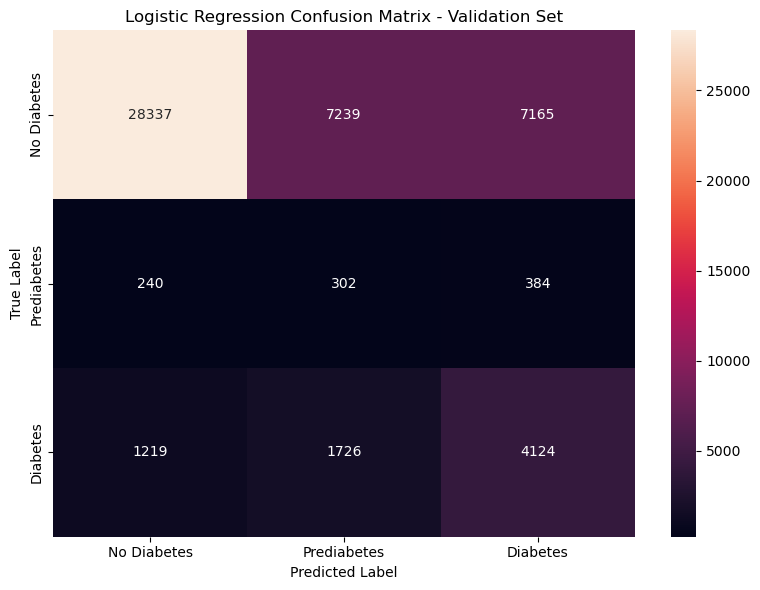

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_lr = confusion_matrix(y_val, y_val_pred_lr)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=["No Diabetes", "Prediabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Prediabetes", "Diabetes"]
)

plt.title("Logistic Regression Confusion Matrix - Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

Logistic Regression Baseline. The Logistic Regression model achieved an accuracy of 64.58%, a balanced accuracy of 52.42%, and a macro F1-score of 42.69% on the validation set. Classification performance varied substantially across the three diabetes-status classes. The model achieved an F1-score of 0.78 and recall of 0.66 for the No Diabetes class, while the Diabetes class achieved a recall of 0.58 and an F1-score of 0.44. In contrast, performance for the minority Prediabetes class was limited, with a precision of 0.03, recall of 0.33, and F1-score of 0.06. The confusion matrix shows that the model correctly classified 28,337 No Diabetes, 302 Prediabetes, and 4,124 Diabetes observations. Of the 926 Prediabetes observations, 302 were correctly identified, while 240 were classified as No Diabetes and 384 as Diabetes. These results highlight the difficulty of accurately identifying the minority Prediabetes class in the imbalanced dataset, despite the use of class weighting.

In [27]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (202944, 21)
y_train: (202944,)
X_val: (50736, 21)
y_val: (50736,)


In [28]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost training completed.")

XGBoost training completed.


In [29]:
y_val_pred_xgb = xgb_model.predict(X_val)

print("XGBoost predictions completed.")

XGBoost predictions completed.


In [30]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy_xgb = accuracy_score(y_val, y_val_pred_xgb)
balanced_acc_xgb = balanced_accuracy_score(y_val, y_val_pred_xgb)
macro_f1_xgb = f1_score(y_val, y_val_pred_xgb, average="macro")

print("XGBoost - Validation Results")
print("-----------------------------")
print(f"Accuracy:          {accuracy_xgb:.4f}")
print(f"Balanced Accuracy: {balanced_acc_xgb:.4f}")
print(f"Macro F1-score:    {macro_f1_xgb:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_val,
    y_val_pred_xgb,
    target_names=["No Diabetes", "Prediabetes", "Diabetes"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_xgb))

XGBoost - Validation Results
-----------------------------
Accuracy:          0.8495
Balanced Accuracy: 0.3885
Macro F1-score:    0.3994

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.86      0.98      0.92     42741
 Prediabetes       0.00      0.00      0.00       926
    Diabetes       0.55      0.19      0.28      7069

    accuracy                           0.85     50736
   macro avg       0.47      0.39      0.40     50736
weighted avg       0.81      0.85      0.81     50736


Confusion Matrix:
[[41769     0   972]
 [  831     0    95]
 [ 5739     0  1330]]


c:\Users\somy\miniconda3_new\envs\mlnew\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\somy\miniconda3_new\envs\mlnew\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\somy\miniconda3_new\envs\mlnew\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

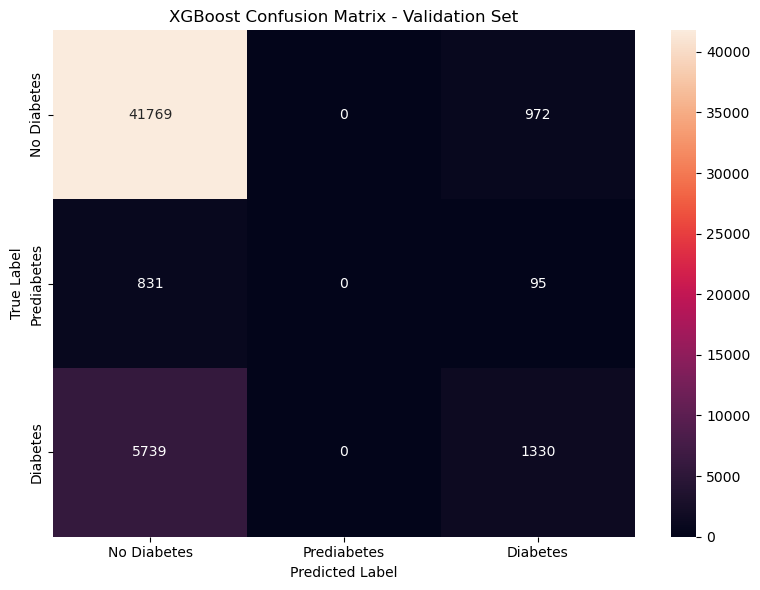

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_xgb = confusion_matrix(y_val, y_val_pred_xgb)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    xticklabels=["No Diabetes", "Prediabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Prediabetes", "Diabetes"]
)

plt.title("XGBoost Confusion Matrix - Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

XGBoost. The XGBoost model achieved an overall accuracy of 84.95%, a balanced accuracy of 38.85%, and a macro F1-score of 39.94% on the validation set. Although the accuracy was relatively high, the class-level results revealed substantial differences in performance across the three diabetes-status classes. The model achieved a recall of 0.98 and an F1-score of 0.92 for the No Diabetes class. In contrast, performance for the minority Prediabetes class was extremely limited, with precision, recall, and F1-score all equal to 0.00. The confusion matrix shows that none of the 926 Prediabetes observations were correctly classified as Prediabetes; 831 were classified as No Diabetes and 95 as Diabetes. The model also achieved a recall of 0.19 and an F1-score of 0.28 for the Diabetes class. These results indicate that the high overall accuracy was strongly influenced by the majority No Diabetes class and did not translate into effective classification of the minority classes. The lower balanced accuracy and macro F1-score further demonstrate the impact of class imbalance on model performance.